# Testing the generation of photo_thin_table and photo_thick_table in BPASSSource against BlackBodySource

Table of contents:

1. [Imports](#imports)

<a id="imports"></a>
## Imports and constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tempfile
from pathlib import Path

import astropy.constants as cst
import astropy.units as u

from pyc2ray.radiation.blackbody import BlackBodySource, BPASSSource
from pyc2ray.radiation.common import make_tau_table

hplanck   = cst.h.cgs.value
k_B       = cst.k_B.cgs.value
c_cgs     = cst.c.cgs.value
c_AA      = cst.c.to(u.AA / u.s).value
Lsun_erg  = cst.L_sun.cgs.value
R_sun_cm  = cst.R_sun.cgs.value

T = 1e5          # K
R = R_sun_cm     # cm

freq_min = (13.598 * u.eV / cst.h).to("Hz").value          # HI threshold
freq_max = 10 * (54.416 * u.eV / cst.h).to("Hz").value     # 10 × HeII threshold

# Smaller NumTau for speed in the notebook — use 20000 for production
minlogtau, maxlogtau, NumTau = -20.0, 4.0, 500
tau, dlogtau = make_tau_table(minlogtau, maxlogtau, NumTau)

print(f"freq_min = {freq_min:.3e} Hz  ({cst.c.cgs.value/freq_min*1e8:.1f} Å)")
print(f"freq_max = {freq_max:.3e} Hz  ({cst.c.cgs.value/freq_max*1e8:.2f} Å)")
print(f"tau grid: {len(tau)} points from 0 to 10^{maxlogtau}")

freq_min = 3.288e+15 Hz  (911.8 Å)
freq_max = 1.316e+17 Hz  (22.78 Å)
tau grid: 501 points from 0 to 10^4.0


# Tabulate BlackBodySource.SED() into mock BPASS format

evaluate BlackBodySource.SED() directly, then convert
to L_lambda [L_sun/Å] for the BPASS file format.

In [3]:
bpass_dir = '/users/cprior/pyC2Ray/pyc2ray/radiation/tests/data/'

bb_src = BlackBodySource(temp=T, grey=False, freq0=freq_min, pl_index=2.8)

# Wavelength grid (Å) — log-spaced for dense sampling at short wavelengths
wl_aa   = np.logspace(np.log10(1.0), np.log10(10000.0), 5000)
freq_hz = c_AA / wl_aa    # Hz, decreasing (BPASSSource handles the reversal)

# Step 1: evaluate BlackBodySource.SED() — this gives photons/s/Hz (R_star=1)
bb_sed_phot = np.array([bb_src.SED(f) for f in freq_hz])   # photons/s/Hz

# Step 2: photons/s/Hz → L_nu [erg/s/Hz]   (multiply by h*nu)
L_nu_erg = bb_sed_phot * hplanck * freq_hz

# Step 3: L_nu [erg/s/Hz] → L_lambda [L_sun/Å]  (L_lambda = L_nu * nu²/c)
L_lambda_Lsun_AA = L_nu_erg * freq_hz**2 / c_AA / Lsun_erg

# Save as mock BPASS file (52 columns: wavelength + 51 identical age columns)
n_age_cols = 51
data       = np.column_stack([wl_aa] + [L_lambda_Lsun_AA] * n_age_cols)

Z_snapped  = BPASSSource._snap_metallicity(0.020)
Z_str      = BPASSSource._metallicity_to_str(Z_snapped)
fname      = f"spectra-bin-imf135_300.z{Z_str}.dat"
np.savetxt(bpass_dir + fname, data)

print(f"Saved: {fname}  (Z={Z_snapped})")
print(f"Wavelength range: {wl_aa.min():.1f} – {wl_aa.max():.0f} Å  ({len(wl_aa)} points)")

Saved: spectra-bin-imf135_300.z01400.dat  (Z=0.014)
Wavelength range: 1.0 – 10000 Å  (5000 points)


## Unit conversion check: BPASSSource.sed_photon vs BlackBodySource.SED()

BPASSSource loads the file and reverses the pipeline:
L_lambda [L_sun/Å] → L_nu [L_sun/Hz] → L_nu [erg/s/Hz] → photons/s/Hz
The recovered sed_photon should be identical to bb_sed_phot up to
floating point precision — before any normalisation is applied.

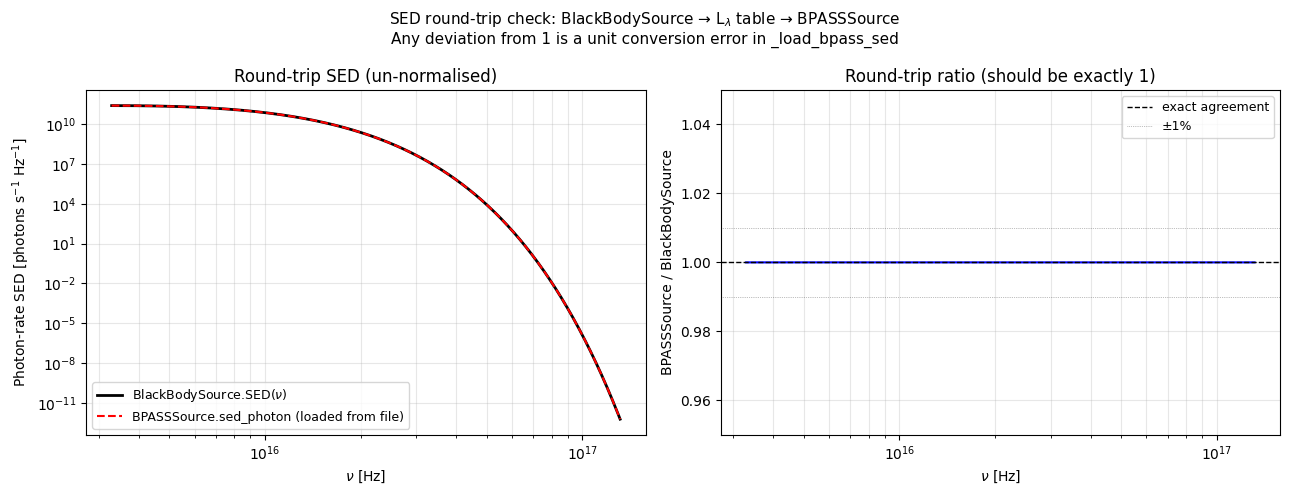

Max round-trip residual: 0.00000%


In [5]:
# BPASSSource loads the file and reverses the pipeline:
#   L_lambda [L_sun/Å] → L_nu [L_sun/Hz] → L_nu [erg/s/Hz] → photons/s/Hz
# The recovered sed_photon should be identical to bb_sed_phot up to
# floating point precision — before any normalisation is applied.

log_age_bins = np.round(np.arange(6.0, 11.05, 0.1), decimals=1)

bpass_src = BPASSSource(
    metallicity  = 0.020,
    age          = 1e7,
    bpass_dir    = bpass_dir,
    grey         = False,
    freq0        = freq_min,
    pl_index     = 2.8,
    log_age_bins = log_age_bins,
)

# BPASSSource stores freqs in increasing order — match bb_sed_phot to that order
bb_sed_sorted = np.array([bb_src.SED(f) for f in bpass_src.freqs])  # photons/s/Hz

mask = (bpass_src.freqs >= freq_min) & (bpass_src.freqs <= freq_max)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.loglog(bpass_src.freqs[mask], bb_sed_sorted[mask],
          "k-",  lw=2,   label=r"BlackBodySource.SED($\nu$)")
ax.loglog(bpass_src.freqs[mask], bpass_src.sed_photon[mask],
          "r--", lw=1.5, label="BPASSSource.sed_photon (loaded from file)")
ax.set_xlabel(r"$\nu$ [Hz]")
ax.set_ylabel("Photon-rate SED [photons s$^{-1}$ Hz$^{-1}$]")
ax.set_title("Round-trip SED (un-normalised)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which="both")

ax = axes[1]
ratio = bpass_src.sed_photon[mask] / bb_sed_sorted[mask]
ax.semilogx(bpass_src.freqs[mask], ratio, "b-", lw=1.5)
ax.axhline(1,    color="k", lw=1,   ls="--", label="exact agreement")
ax.axhline(1.01, color="k", lw=0.5, ls=":",  alpha=0.5)
ax.axhline(0.99, color="k", lw=0.5, ls=":",  alpha=0.5, label="±1%")
ax.set_xlabel(r"$\nu$ [Hz]")
ax.set_ylabel("BPASSSource / BlackBodySource")
ax.set_title("Round-trip ratio (should be exactly 1)")
ax.set_ylim(0.95, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which="both")

plt.suptitle(
    "SED round-trip check: BlackBodySource → L$_\\lambda$ table → BPASSSource\n"
    "Any deviation from 1 is a unit conversion error in _load_bpass_sed",
    fontsize=11,
)
plt.tight_layout()
plt.show()

print(f"Max round-trip residual: {np.abs(ratio - 1).max()*100:.5f}%")

# Quick sanity check: compare the photon-rate SED

Verify the conversion pipeline before computing the full tables.
BPASSSource._load_bpass_sed should recover BlackBodySource.SED(nu) / h*nu.

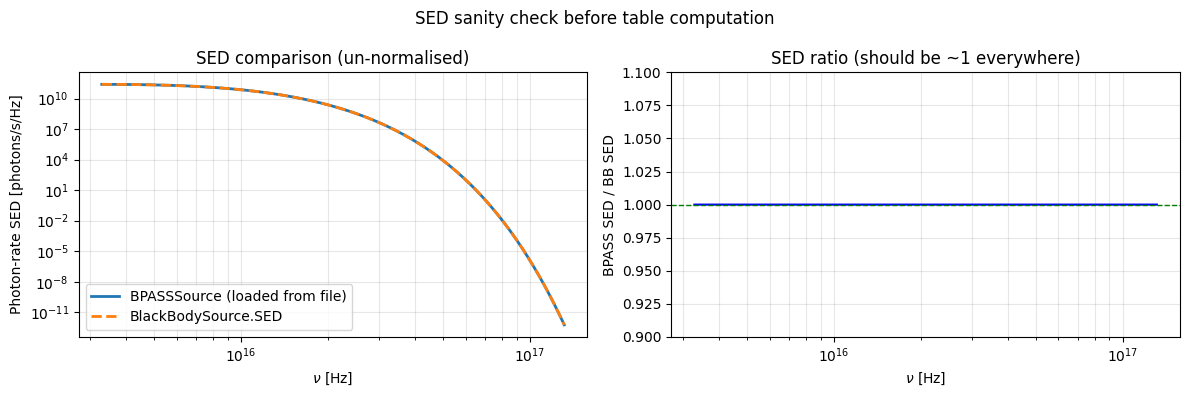

In [6]:
log_age_bins = np.round(np.arange(6.0, 11.05, 0.1), decimals=1)  # 51 bins

bpass_src = BPASSSource(
    metallicity  = 0.020,
    age          = 1e7,       # any age — all columns identical
    bpass_dir    = bpass_dir,
    grey         = False,
    freq0        = freq_min,
    pl_index     = 2.8,
    log_age_bins = log_age_bins,
)

bb_src = BlackBodySource(temp=T, grey=False, freq0=freq_min, pl_index=2.8)

# BlackBodySource.SED is already a photon-rate SED (photons/s/Hz)
bb_sed_photon = np.array([bb_src.SED(f) for f in bpass_src.freqs])

# Mask to ionising range for comparison
mask = (bpass_src.freqs >= freq_min) & (bpass_src.freqs <= freq_max)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.loglog(bpass_src.freqs[mask], bpass_src.sed_photon[mask],
          label="BPASSSource (loaded from file)", lw=2)
ax.loglog(bpass_src.freqs[mask], bb_sed_photon[mask],
          label="BlackBodySource.SED", lw=2, ls="--")
ax.set_xlabel(r"$\nu$ [Hz]")
ax.set_ylabel("Photon-rate SED [photons/s/Hz]")
ax.set_title("SED comparison (un-normalised)")
ax.legend()
ax.grid(True, alpha=0.3, which="both")

ax = axes[1]
ratio_sed = bpass_src.sed_photon[mask] / bb_sed_photon[mask]
ax.semilogx(bpass_src.freqs[mask], ratio_sed, "b-", lw=1.5)
ax.axhline(1, color="green", lw=1, ls="--")
ax.set_xlabel(r"$\nu$ [Hz]")
ax.set_ylabel("BPASS SED / BB SED")
ax.set_title("SED ratio (should be ~1 everywhere)")
ax.set_ylim(0.9, 1.1)
ax.grid(True, alpha=0.3, which="both")

plt.suptitle("SED sanity check before table computation", fontsize=12)
plt.tight_layout()
plt.show()

# Compute photo tables from both sources

This cell is the slow one. With NumTau=500 it takes ~1 min.
With NumTau=20000 (production) it takes ~30 min - use cache_path for that.

In [7]:
print("Computing BlackBodySource tables (quad_vec)...")
bb_thin, bb_thick = bb_src.make_photo_table(tau, freq_min, freq_max, 1e48)
print(f"  thick_table[tau=0] = {bb_thick[0]:.6e}  (should be 1e48)")

print("\nComputing BPASSSource tables (simpson on discrete grid)...")
bpass_thin, bpass_thick = bpass_src.make_photo_table(tau, freq_min, freq_max, 1e48)
print(f"  thick_table[tau=0] = {bpass_thick[0]:.6e}  (should be 1e48)")

Computing BlackBodySource tables (quad_vec)...
  thick_table[tau=0] = 1.000000e+48  (should be 1e48)

Computing BPASSSource tables (simpson on discrete grid)...
  thick_table[tau=0] = 1.000000e+48  (should be 1e48)


# Plot comparison

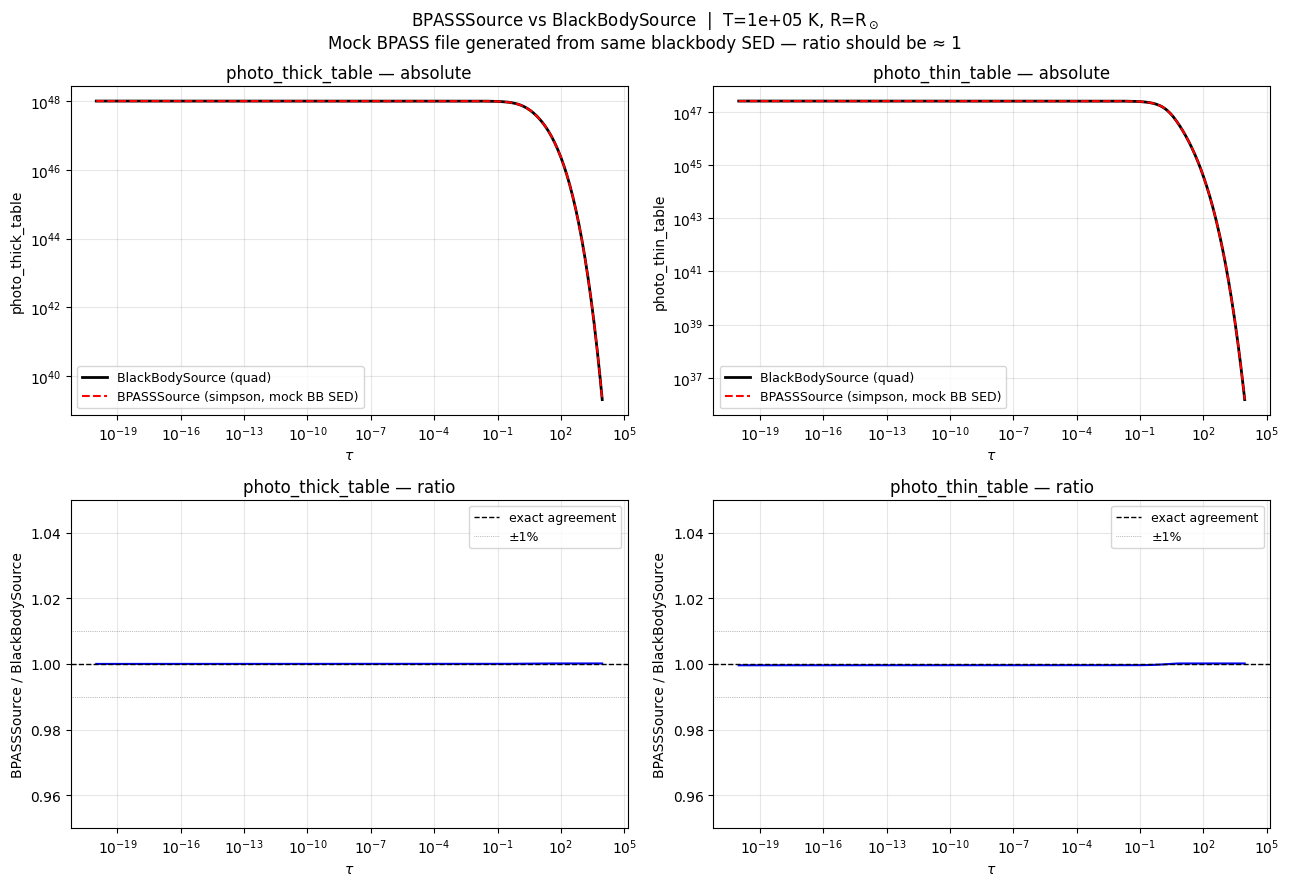

Thick table — max residual: 0.014%
Thin  table — max residual: 0.041%


In [8]:
tau_plot       = tau[1:]          # skip tau=0 for log axes
bb_thin_plot   = bb_thin[1:]
bb_thick_plot  = bb_thick[1:]
bp_thin_plot   = bpass_thin[1:]
bp_thick_plot  = bpass_thick[1:]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Absolute values
for ax, bb_t, bp_t, label in [
    (axes[0, 0], bb_thick_plot, bp_thick_plot, "photo_thick_table"),
    (axes[0, 1], bb_thin_plot,  bp_thin_plot,  "photo_thin_table"),
]:
    ax.loglog(tau_plot, bb_t, "k-",  lw=2,   label="BlackBodySource (quad)")
    ax.loglog(tau_plot, bp_t, "r--", lw=1.5, label="BPASSSource (simpson, mock BB SED)")
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(label)
    ax.set_title(f"{label} — absolute")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, which="both")

# Ratio
for ax, bb_t, bp_t, label in [
    (axes[1, 0], bb_thick_plot, bp_thick_plot, "thick"),
    (axes[1, 1], bb_thin_plot,  bp_thin_plot,  "thin"),
]:
    ratio = bp_t / bb_t
    ax.semilogx(tau_plot, ratio, "b-", lw=1.5)
    ax.axhline(1,    color="k", lw=1,   ls="--", label="exact agreement")
    ax.axhline(1.01, color="k", lw=0.5, ls=":",  alpha=0.5)
    ax.axhline(0.99, color="k", lw=0.5, ls=":",  alpha=0.5, label="±1%")
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel("BPASSSource / BlackBodySource")
    ax.set_title(f"photo_{label}_table — ratio")
    ax.set_ylim(0.95, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, which="both")

plt.suptitle(
    f"BPASSSource vs BlackBodySource  |  T={T:.0e} K, R=R$_\\odot$\n"
    "Mock BPASS file generated from same blackbody SED — ratio should be ≈ 1",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("table_comparison_mock_bpass.png", dpi=150)
plt.show()

# Summary statistics (ignore tau=0 and high tau where values approach 0)
valid = (bp_thick_plot > 1e-10 * bb_thick_plot.max())
print(f"Thick table — max residual: {np.abs(bp_thick_plot[valid]/bb_thick_plot[valid] - 1).max()*100:.3f}%")
print(f"Thin  table — max residual: {np.abs(bp_thin_plot[valid]/bb_thin_plot[valid]   - 1).max()*100:.3f}%")